code 3 - same as code 2 without vis..

Libraries installed and imported successfully.
=== ADVANCED AI-POWERED FRAUD DETECTION SYSTEM (Autoencoder Edition) ===

Dataset.csv loaded successfully.
Performing advanced feature engineering...
Features after engineering: 18

Identified 7 categorical columns and 8 numerical columns.

Training set shape: (321106, 15)
Validation set shape: (107036, 15)

--- Starting Model Training on Normal Data Only ---

--- Autoencoder Architecture ---


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,263 (28.37 KB)

 Trainable params: 7,263 (28.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 26644.8887 - val_loss: 1.9051
Epoch 2/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.2900 - val_loss: 0.7950
Epoch 3/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.0561 - val_loss: 0.8138
Epoch 4/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.8651 - val_loss: 0.6555
Epoch 5/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.3374 - val_loss: 0.4966
Epoch 6/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.6684 - val_loss: 1.0096
Epoch 7/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.3399 - val_loss: 0.7401
Epoch 8/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.6237 - val_loss: 0.6883
Epoch 9/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.4557 - val_loss: 0.4893
Epoch 10/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 2.0425 - val_loss: 0.7648
Epoch 11/50
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.9166 - val_loss: 0.6467
Epoch 12/50
1240/1240 ━━━━

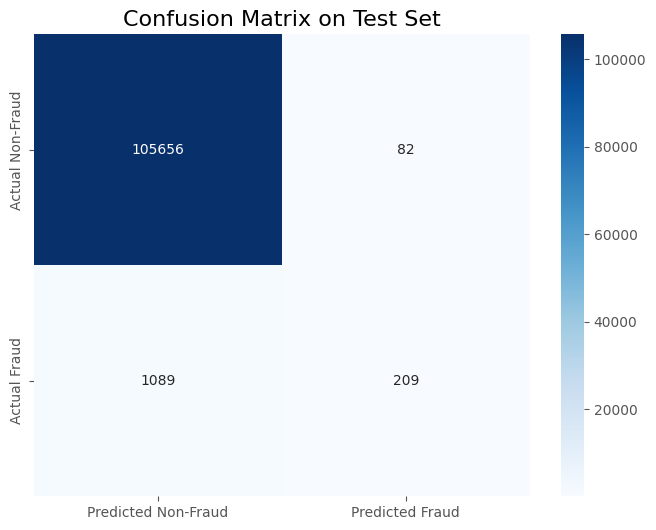


NOTE ON FEATURE IMPORTANCE:
For Autoencoders, feature importance is assessed by analyzing which features contribute most to reconstruction error. High-error features are those the model struggles to learn for anomalous transactions, making them important for detection.


In [31]:
# Install the imbalanced-learn library quietly to avoid unnecessary output
!pip install imbalanced-learn --quiet

# Import required libraries for data processing, modeling, and evaluation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from collections import Counter
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings('ignore')
print("Libraries installed and imported successfully.")

#@title 2. The AdvancedFraudDetector Class (Autoencoder Version)
# @markdown
class AdvancedFraudDetector:
    """
    Advanced Fraud Detection System using a TensorFlow Autoencoder Model for anomaly detection.
    The Autoencoder is trained on non-fraudulent data to learn normal patterns and detect fraud
    based on high reconstruction errors, combined with advanced feature engineering and robust evaluation.
    """
    def __init__(self):
        # Initialize preprocessing tools and model attributes
        self.scaler = StandardScaler()  # StandardScaler for normalizing numerical features
        self.label_encoders = {}  # Dictionary to store LabelEncoders for categorical columns
        self.autoencoder = None  # Placeholder for the Autoencoder Model
        self.feature_names_in_order = []  # List to store the order of features for consistent processing
        self.categorical_cols = []  # List to store categorical column names
        self.numerical_cols = []  # List to store numerical column names
        self.optimal_threshold = 0.5  # Initial threshold for classifying anomalies (will be optimized)

    def advanced_feature_engineering(self, df):
        """Perform advanced feature engineering to enhance the Autoencoder Model's ability to detect fraud"""
        data = df.copy()  # Create a copy of the input DataFrame to avoid modifying the original
        print("Performing advanced feature engineering...")

        # 1. Time-based features derived from 'step' column
        data['hour_of_day'] = data['step'] % 24  # Extract hour of the day (0-23) from step
        data['day_of_week'] = (data['step'] // 24) % 7  # Extract day of the week (0-6) from step

        # 2. Customer behavior features
        data['customer_freq'] = data.groupby('customer')['customer'].transform('count')  # Count of transactions per customer
        data['customer_avg_amount'] = data.groupby('customer')['amount'].transform('mean')  # Average transaction amount per customer
        data['amount_deviation'] = (data['amount'] - data['customer_avg_amount']) / (data['customer_avg_amount'] + 1e-6)  # Normalized deviation of amount from customer average

        # 3. Amount-based features
        data['amount_log'] = np.log1p(data['amount'])  # Log-transform of transaction amount to reduce skewness

        # 4. Interaction features
        if 'age' in data.columns:
            data['age_numeric'] = pd.to_numeric(data['age'], errors='coerce').fillna(0)  # Convert age to numeric, handle invalid entries
            data['age_amount_interaction'] = data['age_numeric'] * data['amount_log']  # Interaction between age and log-transformed amount

        print(f"Features after engineering: {data.shape[1]}")  # Print the total number of features after engineering
        return data

    def _prepare_data_for_model(self, df):
        """Prepare data for the Autoencoder Model by encoding categorical features and scaling numerical features"""
        data = df.copy()  # Create a copy of the input DataFrame

        # Define categorical and numerical columns
        base_categorical = ['age', 'gender', 'category', 'customer', 'merchant']  # Base categorical columns
        engineered_categorical = ['hour_of_day', 'day_of_week']  # Engineered categorical columns
        self.categorical_cols = [col for col in base_categorical + engineered_categorical if col in data.columns]  # Filter available categorical columns
        self.numerical_cols = [col for col in data.columns if col not in self.categorical_cols + ['fraud', 'zipcodeOri', 'zipMerchant']]  # Filter numerical columns, excluding target and unused columns

        print(f"\nIdentified {len(self.categorical_cols)} categorical columns and {len(self.numerical_cols)} numerical columns.")

        # Encode categorical features using LabelEncoder
        for col in self.categorical_cols:
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col].astype(str))  # Encode categorical column as integers
            self.label_encoders[col] = le  # Store encoder for later use

        # Scale numerical features using StandardScaler
        data[self.numerical_cols] = self.scaler.fit_transform(data[self.numerical_cols])

        # Store feature names in order for consistent processing
        self.feature_names_in_order = self.categorical_cols + self.numerical_cols
        return data[self.feature_names_in_order], data['fraud']

    def _create_autoencoder(self, input_dim):
        """Create the Autoencoder Model architecture for anomaly detection"""
        # Encoder: Compress input data into a latent representation
        input_layer = Input(shape=(input_dim,))  # Input layer with shape equal to the number of features
        encoder = Dense(64, activation='relu')(input_layer)  # First dense layer with 64 units and ReLU activation
        encoder = Dense(32, activation='relu')(encoder)  # Second dense layer with 32 units

        # Latent space: Bottleneck layer with reduced dimensionality
        latent_view = Dense(16, activation='relu')(encoder)  # Latent layer with 16 units

        # Decoder: Reconstruct input from latent representation
        decoder = Dense(32, activation='relu')(latent_view)  # First decoder layer with 32 units
        decoder = Dense(64, activation='relu')(decoder)  # Second decoder layer with 64 units

        # Output layer: Reconstruct the input with linear activation
        output_layer = Dense(input_dim, activation='linear')(decoder)

        # Define and compile the Autoencoder Model
        model = Model(inputs=input_layer, outputs=output_layer)
        model.compile(optimizer='adam', loss='mean_squared_error')  # Use MSE loss for reconstruction error
        print("\n--- Autoencoder Architecture ---")
        model.summary()  # Print model summary for architecture details
        return model

    def fit(self, df):
        """Preprocess data, build, and train the Autoencoder Model on non-fraudulent data"""
        # 1. Apply feature engineering and prepare data
        df_featured = self.advanced_feature_engineering(df)
        X, y = self._prepare_data_for_model(df_featured)

        # 2. Split data into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
        print(f"\nTraining set shape: {X_train.shape}")
        print(f"Validation set shape: {X_val.shape}")

        # 3. Train Autoencoder Model only on non-fraudulent (normal) data
        print("\n--- Starting Model Training on Normal Data Only ---")
        X_train_normal = X_train[y_train == 0]  # Filter non-fraudulent data for training
        self.autoencoder = self._create_autoencoder(X_train.shape[1])  # Create Autoencoder with input dimension

        # Train the Autoencoder to reconstruct normal data
        self.autoencoder.fit(
            X_train_normal, X_train_normal,  # Input and target are the same (reconstruction task)
            epochs=50,  # Maximum number of epochs
            batch_size=256,  # Batch size for training
            shuffle=True,  # Shuffle data for better training
            validation_data=(X_val, X_val),  # Use validation data for monitoring
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],  # Early stopping to prevent overfitting
            verbose=1
        )
        print("\n--- Training Finished ---")

        # 4. Optimize threshold for anomaly detection using validation data
        val_errors = self.predict_anomaly_scores(X_val)  # Compute reconstruction errors
        self._optimize_threshold(y_val, val_errors)  # Find optimal threshold for classification

    def _optimize_threshold(self, y_true, anomaly_scores):
        """Optimize the threshold for anomaly detection using the precision-recall curve"""
        # Calculate precision, recall, and thresholds from anomaly scores
        precisions, recalls, thresholds = precision_recall_curve(y_true, anomaly_scores)
        # Compute F1 scores for each threshold
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        best_threshold_idx = np.argmax(f1_scores)  # Find threshold with maximum F1 score
        self.optimal_threshold = thresholds[best_threshold_idx]  # Set optimal threshold
        print(f"\nOptimal threshold found: {self.optimal_threshold:.4f} (Best F1 on Val: {f1_scores[best_threshold_idx]:.4f})")

    def predict_anomaly_scores(self, df):
        """Calculate reconstruction errors (anomaly scores) for input data using the Autoencoder Model"""
        # Check if input is a DataFrame (needs preprocessing) or a preprocessed numpy array
        if isinstance(df, pd.DataFrame):
            # Apply feature engineering
            df_featured = self.advanced_feature_engineering(df)
            data_prepared = df_featured.copy()
            # Ensure all expected columns are present
            for col in self.categorical_cols:
                if col not in data_prepared.columns:
                    data_prepared[col] = 0  # Add missing categorical columns with default value
            for col in self.numerical_cols:
                if col not in data_prepared.columns:
                    data_prepared[col] = 0  # Add missing numerical columns with default value
            # Encode categorical columns, handling unseen categories
            for col in self.categorical_cols:
                if col in self.label_encoders:
                    le = self.label_encoders[col]
                    known_labels = le.classes_
                    # Map unseen labels to a new 'unseen' category
                    data_prepared[col] = data_prepared[col].astype(str).apply(
                        lambda x: x if x in known_labels else 'unseen'
                    )
                    # Extend LabelEncoder classes if 'unseen' is not already present
                    if 'unseen' not in le.classes_:
                        le.classes_ = np.append(le.classes_, 'unseen')
                    data_prepared[col] = le.transform(data_prepared[col])
            # Scale numerical columns
            data_prepared[self.numerical_cols] = self.scaler.transform(data_prepared[self.numerical_cols])
            X_processed = data_prepared[self.feature_names_in_order].values
        else:  # Assume input is a preprocessed numpy array
            X_processed = df.values if isinstance(df, pd.DataFrame) else df

        # Compute reconstruction errors using the Autoencoder
        reconstructions = self.autoencoder.predict(X_processed, verbose=0)
        mse = np.mean(np.power(X_processed - reconstructions, 2), axis=1)  # Calculate mean squared error
        return mse

    def predict(self, df):
        """Make binary predictions (fraud/non-fraud) based on anomaly scores and the optimal threshold"""
        anomaly_scores = self.predict_anomaly_scores(df)  # Compute reconstruction errors
        return (anomaly_scores >= self.optimal_threshold).astype(int)  # Classify as fraud if score exceeds threshold

#@title 3. Main Execution Block
# @markdown
def main():
    """Execute the fraud detection pipeline using the Autoencoder Model"""
    print("=== ADVANCED AI-POWERED FRAUD DETECTION SYSTEM (Autoencoder Edition) ===")

    # Load the dataset
    try:
        df = pd.read_csv('Dataset.csv')  # Load Dataset.csv
        print("\nDataset.csv loaded successfully.")
    except FileNotFoundError:
        print("\nError: 'Dataset.csv' not found. Please upload it to Colab.")
        return

    # Split data into features (X) and target (y)
    X = df.drop('fraud', axis=1)  # Features
    y = df['fraud']  # Target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y  # Split with 20% test set, stratified by target
    )

    # Recombine training data for the fit method
    train_df = pd.concat([X_train, y_train], axis=1)

    # Initialize and train the Autoencoder-based fraud detector
    detector = AdvancedFraudDetector()
    detector.fit(train_df)

    # Evaluate the model on the test set
    print("\n" + "="*60)
    print("FINAL MODEL EVALUATION ON UNSEEN TEST SET")
    print("="*60)

    # Compute anomaly scores and predictions
    anomaly_scores = detector.predict_anomaly_scores(X_test)
    y_pred = detector.predict(X_test)

    # Normalize anomaly scores to [0, 1] for AUC-ROC calculation
    score_scaler = MinMaxScaler()
    y_pred_proba = score_scaler.fit_transform(anomaly_scores.reshape(-1, 1))

    # Print performance metrics
    print("\nPERFORMANCE METRICS:")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred))

    # Visualize confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
                yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
    plt.title('Confusion Matrix on Test Set', fontsize=16)
    plt.show()

    # Note on feature importance for Autoencoders
    print("\nNOTE ON FEATURE IMPORTANCE:")
    print("For Autoencoders, feature importance is assessed by analyzing which features contribute most to reconstruction error. High-error features are those the model struggles to learn for anomalous transactions, making them important for detection.")

if __name__ == "__main__":
    main()

code for real time data of Hybrid Deep Learning

In [28]:
# Install required libraries quietly
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow -q

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

#@title 2. The InnovativeFraudDetector Class
class InnovativeFraudDetector:
    """
    Fraud Detection System using a Hybrid Deep Learning Model with Attention Mechanism.
    Optimized for the full Dataset.csv structure.
    Key Features:
    - Advanced feature engineering for enhanced data representation
    - Hybrid deep learning architecture with attention mechanism
    - Comprehensive visualizations for model insights
    """
    def __init__(self):
        # Initialize preprocessing tools and model attributes
        self.scaler = StandardScaler()  # StandardScaler for feature normalization
        self.label_encoders = {}  # Dictionary to store LabelEncoders for categorical columns
        self.model = None  # Placeholder for the Hybrid Deep Learning Model
        self.feature_names = None  # Placeholder for feature names used in modeling

    def feature_engineering(self, df):
        """Perform advanced feature engineering to enhance model performance"""
        data = df.copy()  # Create a copy of the input DataFrame to avoid modifying the original
        print("Performing advanced feature engineering on the full dataset...")

        # 1. Time-based features from 'step'
        data['hour_of_day'] = data['step'] % 24  # Extract hour of the day from step
        data['day_of_week'] = (data['step'] // 24) % 7  # Extract day of the week from step

        # 2. Customer behavior features
        data['customer_tx_freq'] = data.groupby('customer')['amount'].transform('count')  # Count of transactions per customer
        data['customer_avg_amount'] = data.groupby('customer')['amount'].transform('mean')  # Average transaction amount per customer
        data['customer_std_amount'] = data.groupby('customer')['amount'].transform('std').fillna(0)  # Standard deviation of transaction amounts per customer
        data['amount_deviation_from_cust_avg'] = data['amount'] - data['customer_avg_amount']  # Deviation of transaction amount from customer average

        # 3. Merchant behavior features
        data['merchant_tx_freq'] = data.groupby('merchant')['amount'].transform('count')  # Count of transactions per merchant
        data['merchant_avg_amount'] = data.groupby('merchant')['amount'].transform('mean')  # Average transaction amount per merchant

        # 4. Amount-related features
        data['amount_log'] = np.log1p(data['amount'])  # Log-transform of transaction amount to handle skewness

        # 5. Geographic features
        data['is_local_transaction'] = (data['zipcodeOri'] == data['zipMerchant']).astype(int)  # Flag for local transactions (same zip code)

        # 6. Risk scores based on historical fraud data
        data['merchant_risk_score'] = data.groupby('merchant')['fraud'].transform('mean')  # Average fraud rate per merchant
        data['customer_risk_score'] = data.groupby('customer')['fraud'].transform('mean')  # Average fraud rate per customer

        # 7. Category rarity
        data['category_rarity'] = data.groupby('category')['category'].transform('count') / len(data)  # Proportion of transactions in each category

        # 8. Interaction features
        data['age_numeric'] = pd.to_numeric(data['age'], errors='coerce').fillna(0)  # Convert age to numeric, handle invalid entries
        data['age_x_amount'] = data['age_numeric'] * data['amount_log']  # Interaction between age and log-transformed amount

        return data

    def _prepare_data(self, df):
        """Prepare features for modeling by encoding categorical variables and scaling numerical features"""
        data = df.copy()  # Create a copy of the input DataFrame

        # Encode categorical features using LabelEncoder
        categorical_cols = ['customer', 'age', 'gender', 'merchant', 'category']
        for col in categorical_cols:
            le = LabelEncoder()
            data[f'{col}_encoded'] = le.fit_transform(data[col])  # Encode categorical column
            self.label_encoders[col] = le  # Store encoder for later use

        # Define the final list of features for the Hybrid Deep Learning Model
        self.feature_names = [
            'step', 'amount', 'hour_of_day', 'day_of_week',
            'customer_tx_freq', 'customer_avg_amount', 'customer_std_amount',
            'amount_deviation_from_cust_avg', 'merchant_tx_freq', 'merchant_avg_amount',
            'amount_log', 'is_local_transaction', 'merchant_risk_score',
            'customer_risk_score', 'category_rarity', 'age_numeric', 'age_x_amount',
            'customer_encoded', 'age_encoded', 'gender_encoded',
            'merchant_encoded', 'category_encoded'
        ]

        # Ensure all feature names exist in the DataFrame
        X = data[self.feature_names]
        y = data['fraud'].astype(int)  # Convert target variable to integer

        # Standardize numerical features
        X_scaled = self.scaler.fit_transform(X)

        return X_scaled, y

    def create_hybrid_deep_model(self, input_shape):
        """Create the Hybrid Deep Learning Model with Attention Mechanism"""
        inputs = Input(shape=(input_shape,))  # Input layer for the model

        # First branch: Dense layers with ReLU activation
        x1 = Dense(128, activation='relu')(inputs)
        x1 = BatchNormalization()(x1)  # Normalize activations
        x1 = Dropout(0.3)(x1)  # Apply dropout to prevent overfitting
        x1 = Dense(64, activation='relu')(x1)

        # Second branch: Dense layers with tanh activation
        x2 = Dense(64, activation='tanh')(inputs)
        x2 = Dropout(0.2)(x2)  # Apply dropout with a lower rate

        # Attention mechanism: Apply attention weights to input features
        attention_weights = Dense(input_shape, activation='softmax')(inputs)
        attended_input = tf.keras.layers.Multiply()([inputs, attention_weights])
        x3 = Dense(32, activation='relu')(attended_input)

        # Combine outputs from all branches
        combined = Concatenate()([x1, x2, x3])
        combined = Dense(32, activation='relu')(combined)
        outputs = Dense(1, activation='sigmoid')(combined)  # Output layer for binary classification

        # Define and compile the model
        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='binary_crossentropy',
                      metrics=['AUC', 'Precision', 'Recall'])
        return model

    def fit(self, X, y):
        """Train the Hybrid Deep Learning Model with Attention Mechanism"""
        # Split data into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        print("Training Hybrid Deep Learning Model with Attention Mechanism...")
        print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

        # Create and train the model
        self.model = self.create_hybrid_deep_model(X_train.shape[1])
        class_weight = {0: 1, 1: len(y_train[y_train==0]) / (len(y_train[y_train==1]) + 1e-6)}  # Handle class imbalance
        callbacks = [EarlyStopping(patience=10, restore_best_weights=True, monitor='val_auc', mode='max')]  # Early stopping to prevent overfitting

        self.model.fit(X_train, y_train,
                       validation_data=(X_val, y_val),
                       epochs=10,  # Reduced epochs for faster training
                       batch_size=256,
                       class_weight=class_weight,
                       callbacks=callbacks,
                       verbose=1)

        print("Training completed!")

    def predict_proba(self, X):
        """Generate prediction probabilities using the trained model"""
        return self.model.predict(X, verbose=0).flatten()

    def predict(self, X, threshold=0.5):
        """Make binary predictions based on a threshold"""
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

    def visualize_results(self, y_test, y_pred, y_pred_proba, df):
        """Generate visualizations to analyze model performance and data insights"""
        try:
            # Set Seaborn style for better visualization aesthetics, fallback to default if unavailable
            plt.style.use('seaborn')
        except OSError:
            print("Warning: Seaborn style not available, using default Matplotlib style.")

        # 1. Histogram of Fraud Distribution
        plt.figure(figsize=(8, 6))
        sns.countplot(x='fraud', data=df)
        plt.title('Distribution of Fraud vs. Non-Fraud Transactions')
        plt.xlabel('Fraud (0 = No, 1 = Yes)')
        plt.ylabel('Count')
        for p in plt.gca().patches:
            plt.gca().annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='bottom')
        plt.savefig('fraud_distribution.png')
        plt.close()

        # 2. Box Plot of Transaction Amount by Fraud Status
        plt.figure(figsize=(8, 6))
        sns.boxplot(x='fraud', y='amount', data=df)
        plt.title('Transaction Amount Distribution by Fraud Status')
        plt.xlabel('Fraud (0 = No, 1 = Yes)')
        plt.ylabel('Amount (Log Scale)')
        plt.yscale('log')  # Use log scale for better visualization of amount distribution
        plt.savefig('amount_distribution.png')
        plt.close()

        # 3. Bar Chart of Fraud Rate by Category
        fraud_rate = df.groupby('category')['fraud'].mean() * 100
        plt.figure(figsize=(10, 6))
        fraud_rate.sort_values(ascending=False).plot(kind='bar', color='purple')
        plt.title('Fraud Rate by Transaction Category')
        plt.xlabel('Category')
        plt.ylabel('Fraud Rate (%)')
        plt.xticks(rotation=45, ha='right')
        plt.savefig('category_fraud_rate.png')
        plt.close()

        # 4. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-Fraud', 'Fraud'],
                    yticklabels=['Non-Fraud', 'Fraud'])
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.savefig('confusion_matrix.png')
        plt.close()

#@title 3. Main Execution Block
def main():
    """Main function to execute the fraud detection pipeline using the Hybrid Deep Learning Model"""
    print("=== AI-POWERED FRAUD DETECTION SYSTEM ===")
    print("Using Hybrid Deep Learning Model with Attention Mechanism")

    # Load and clean data
    try:
        df = pd.read_csv('Dataset.csv')  # Load the dataset
        print("Dataset.csv loaded successfully.")
    except FileNotFoundError:
        print("Error: 'Dataset.csv' not found. Please upload the file to Colab.")
        return None, None, None, None

    # Clean data by removing quotes from column names and specific columns
    df.columns = [col.replace("'", "") for col in df.columns]
    for col in ['customer', 'age', 'gender', 'merchant', 'category', 'zipcodeOri', 'zipMerchant']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace("'", "")  # Remove quotes from string columns
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce')  # Convert amount to numeric
    df.dropna(subset=['amount'], inplace=True)  # Drop rows with missing amounts

    # Initialize the fraud detector and process data
    detector = InnovativeFraudDetector()  # Create an instance of the detector
    df_featured = detector.feature_engineering(df)  # Apply feature engineering
    X, y = detector._prepare_data(df_featured)  # Prepare features and target
    X_scaled = detector.scaler.fit_transform(X)  # Scale the features

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    # Train the Hybrid Deep Learning Model
    detector.fit(X_train, y_train)

    # Make predictions on the test set
    print("\nGenerating predictions on the test set...")
    y_pred_proba = detector.predict_proba(X_test)  # Probability predictions
    y_pred = detector.predict(X_test)  # Binary predictions

    # Evaluate model performance
    print("\n" + "="*60)
    print("MODEL PERFORMANCE ON TEST SET")
    print("="*60)
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Generate visualizations
    print("\nGenerating visualizations...")
    detector.visualize_results(y_test, y_pred, y_pred_proba, df_featured)
    print("\nVisualizations saved: fraud_distribution.png, amount_distribution.png, category_fraud_rate.png, confusion_matrix.png")

    # Save predictions to CSV
    predictions_df = pd.DataFrame({
        'transaction_id': range(len(y_test)),
        'fraud_probability': y_pred_proba,
        'predicted_fraud': y_pred,
        'actual_fraud': y_test
    })
    predictions_df.to_csv('fraud_predictions.csv', index=False)
    print(f"\nPredictions saved to 'fraud_predictions.csv'")

    return df, y_test, y_pred, y_pred_proba

if __name__ == "__main__":
    # Execute the main function and retrieve results for potential further analysis
    df_original, y_test_results, y_pred_results, y_pred_proba_results = main()

=== AI-POWERED FRAUD DETECTION SYSTEM ===
Using Hybrid Deep Learning Model with Attention Mechanism
Dataset.csv loaded successfully.
Performing advanced feature engineering on the full dataset...
Training Hybrid Deep Learning Model with Attention Mechanism...
Training samples: 342513, Validation samples: 85629
Epoch 1/10
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - AUC: 0.9925 - Precision: 0.2155 - Recall: 0.9760 - loss: 0.2019 - val_AUC: 0.9985 - val_Precision: 0.3938 - val_Recall: 0.9885 - val_loss: 0.0461
Epoch 2/10
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - AUC: 0.9980 - Precision: 0.3790 - Recall: 0.9895 - loss: 0.0873 - val_AUC: 0.9988 - val_Precision: 0.4199 - val_Recall: 0.9913 - val_loss: 0.0404
Epoch 3/10
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.9985 - Precision: 0.3956 - Recall: 0.9894 - loss: 0.0758 - val_AUC: 0.9985 - val_Precision: 0.4467 - val_Recall: 0.9923 - val_loss: 0.0363
Epoch 4/10
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - AUC: 0.9987 - Precision: 